In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report, confusion_matrix

In [17]:
df = pd.read_csv('dataset.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [19]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [20]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

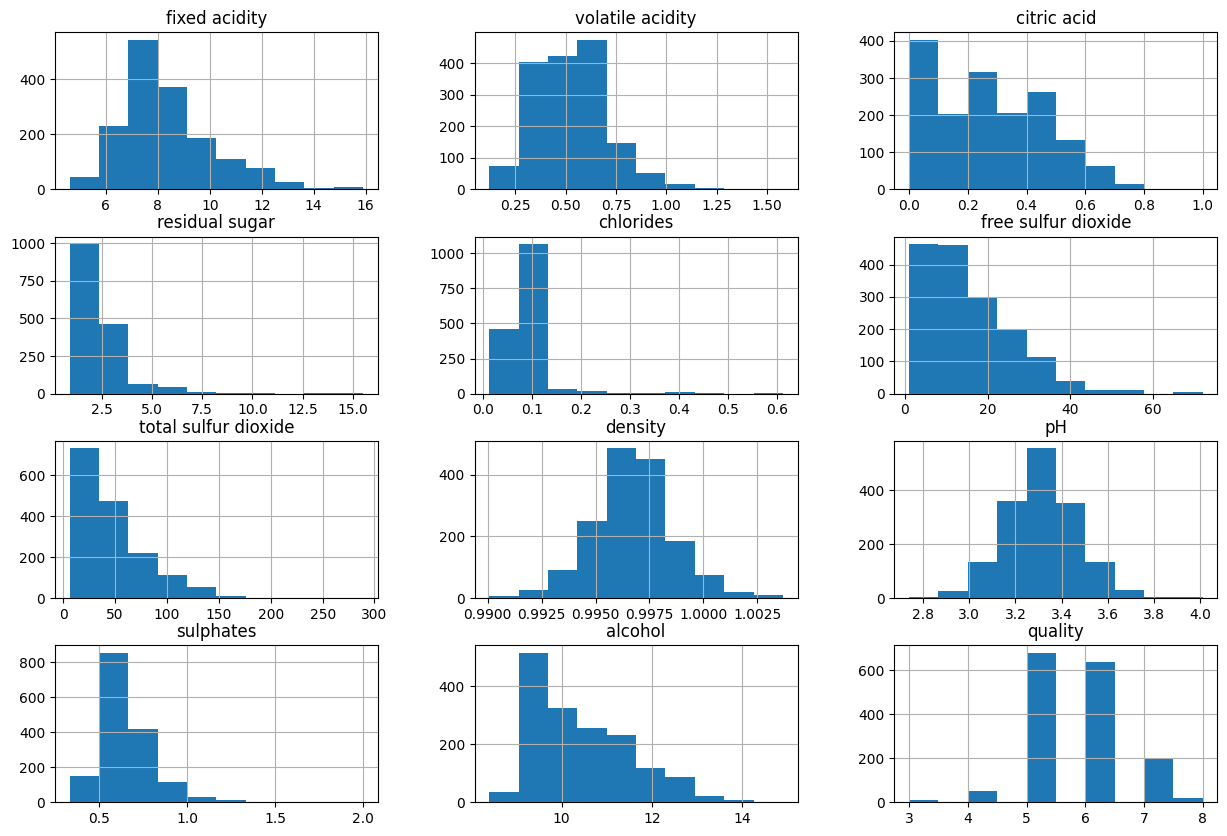

In [21]:
df.hist(df.columns, figsize=(15, 10))

In [22]:
X = df.drop(columns=['quality']).values
y = df['quality'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
rf_rgg = RandomForestClassifier(n_estimators=20, random_state=42)
rf_rgg.fit(X_train, y_train)
y_pred = rf_rgg.predict(X_test)
y_pred

array([5, 5, 5, 5, 6, 5, 5, 5, 6, 6, 7, 5, 6, 6, 5, 6, 5, 6, 7, 5, 5, 6,
       5, 6, 5, 6, 7, 5, 5, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 6, 5, 5, 6, 5,
       6, 6, 7, 6, 5, 6, 5, 5, 6, 7, 5, 6, 6, 5, 6, 5, 5, 6, 6, 5, 7, 6,
       7, 6, 7, 5, 6, 5, 6, 6, 6, 5, 7, 5, 5, 6, 5, 7, 5, 6, 6, 6, 5, 6,
       7, 5, 6, 6, 5, 5, 5, 5, 5, 6, 5, 6, 5, 5, 6, 7, 6, 7, 6, 5, 6, 5,
       7, 5, 6, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 5, 6, 5, 6, 5, 5, 6, 6, 5,
       5, 6, 6, 5, 5, 5, 5, 6, 7, 6, 7, 5, 6, 5, 6, 6, 6, 5, 6, 6, 6, 5,
       6, 5, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 7, 5, 7, 6,
       6, 5, 5, 5, 5, 7, 5, 6, 5, 6, 6, 6, 7, 5, 5, 6, 5, 6, 6, 5, 5, 6,
       5, 7, 5, 5, 5, 5, 6, 6, 5, 6, 6, 6, 8, 5, 5, 6, 6, 4, 6, 5, 6, 6,
       6, 6, 6, 6, 6, 5, 5, 7, 5, 5, 5, 5, 6, 6, 5, 7, 5, 6, 6, 5, 5, 5,
       6, 7, 6, 7, 6, 5, 6, 5, 6, 5, 5, 6, 6, 5, 5, 4, 6, 6, 6, 6, 5, 7,
       6, 6, 5, 5, 6, 6, 5, 6, 5, 6, 6, 6, 6, 6, 6, 6, 7, 5, 5, 5, 5, 7,
       5, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 7, 6, 6, 5,

In [ ]:
cf = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cf)
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.66
Confusion Matrix:
 [[ 0  0  1  0  0  0]
 [ 0  0  6  4  0  0]
 [ 0  0 98 32  0  0]
 [ 0  1 31 94  6  0]
 [ 0  1  1 19 20  1]
 [ 0  0  0  1  4  0]]
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.71      0.67       132
           7       0.67      0.48      0.56        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.32      0.33       320
weighted avg       0.64      0.66      0.65       320



C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:156

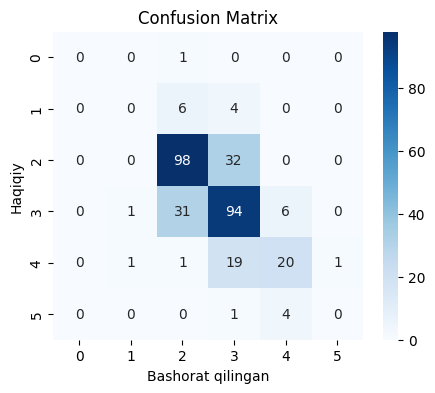

In [32]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Bashorat qilingan")
plt.ylabel("Haqiqiy")
plt.title("Confusion Matrix")
plt.show()

In [24]:
rf_reg = RandomForestRegressor(n_estimators=20, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)
y_pred

array([5.25, 5.15, 5.35, 5.05, 6.  , 5.  , 5.1 , 5.  , 6.2 , 5.85, 6.75,
       5.1 , 5.9 , 5.35, 5.5 , 6.35, 5.35, 5.75, 6.85, 5.15, 4.85, 5.9 ,
       5.25, 5.95, 5.7 , 6.  , 6.7 , 5.25, 5.25, 5.85, 5.35, 5.3 , 5.95,
       5.75, 5.75, 5.05, 6.55, 5.9 , 5.35, 6.25, 5.2 , 5.25, 6.15, 5.05,
       5.65, 5.5 , 6.35, 5.55, 5.15, 5.65, 5.05, 5.25, 5.65, 7.15, 5.25,
       5.55, 6.  , 5.85, 5.55, 5.  , 5.75, 5.95, 5.6 , 5.55, 6.8 , 5.3 ,
       6.55, 5.65, 6.9 , 5.6 , 6.05, 5.2 , 6.  , 5.6 , 6.05, 5.15, 6.4 ,
       5.15, 5.8 , 6.55, 5.3 , 6.85, 5.2 , 5.6 , 5.85, 6.4 , 5.1 , 6.05,
       6.4 , 5.6 , 6.3 , 5.8 , 5.  , 5.2 , 5.35, 5.5 , 5.05, 6.  , 4.6 ,
       5.45, 4.9 , 4.85, 5.65, 6.55, 5.35, 6.65, 5.85, 5.35, 5.6 , 5.35,
       6.5 , 4.95, 6.05, 5.  , 5.15, 6.  , 5.25, 5.35, 5.3 , 5.6 , 6.3 ,
       5.55, 5.6 , 5.45, 5.65, 5.45, 6.45, 5.55, 5.25, 5.6 , 6.  , 5.4 ,
       5.05, 6.55, 5.65, 5.2 , 4.85, 5.45, 5.3 , 5.9 , 6.6 , 6.2 , 6.6 ,
       5.05, 5.6 , 5.1 , 5.65, 5.6 , 5.4 , 5.05, 5.

In [ ]:
mean_squared_error(y_test, y_pred)

0.4375

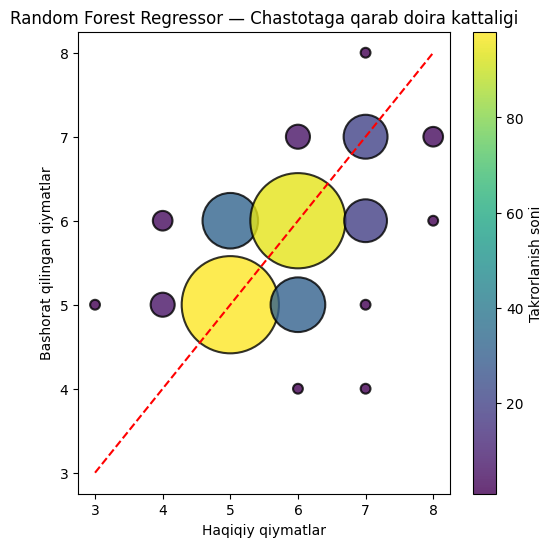

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

points = np.round(np.column_stack((y_test, y_pred)), 2)  
unique_points, counts = np.unique(points, axis=0, return_counts=True)


sizes = counts * 50      
colors = counts         

plt.figure(figsize=(6,6))
scatter = plt.scatter(unique_points[:,0], unique_points[:,1],
                      s=sizes, c=colors, cmap='viridis',
                      edgecolor='black', linewidth=1.5, alpha=0.8)

# Ideal chiziq
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

plt.xlabel("Haqiqiy qiymatlar")
plt.ylabel("Bashorat qilingan qiymatlar")
plt.title("Random Forest Regressor — Chastotaga qarab doira kattaligi")
plt.colorbar(scatter, label="Takrorlanish soni")
plt.show()

